# Load cleaned data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# load data from global_weather_cleaded.csv

df = pd.read_csv('./global_weather_cleaned.csv')
df.shape

(144034, 32)

# Weather Relationships

## Temperature vs Humidity

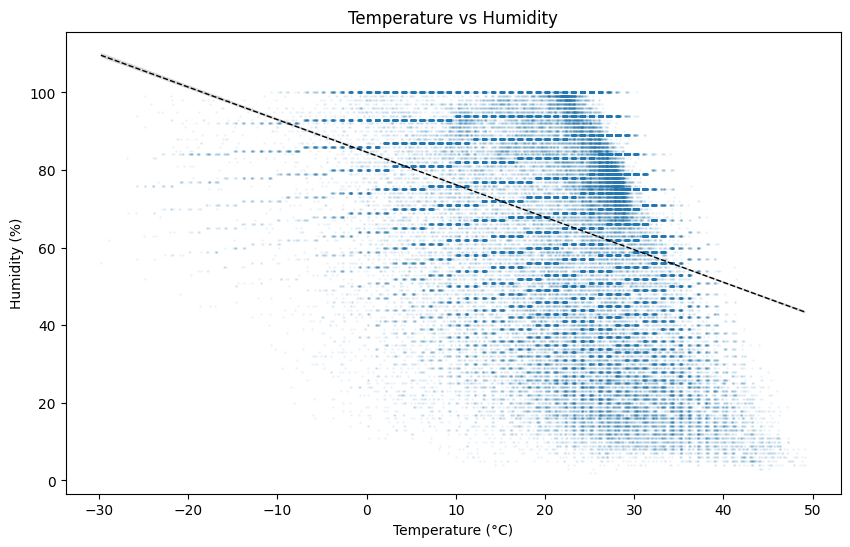

In [12]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='temperature_celsius',
    y='humidity',
    scatter_kws={'s':1, 'alpha':0.05},
    line_kws={'linewidth':1, 'color':'black', 'linestyle':'--'}
)

plt.title('Temperature vs Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')

plt.show()

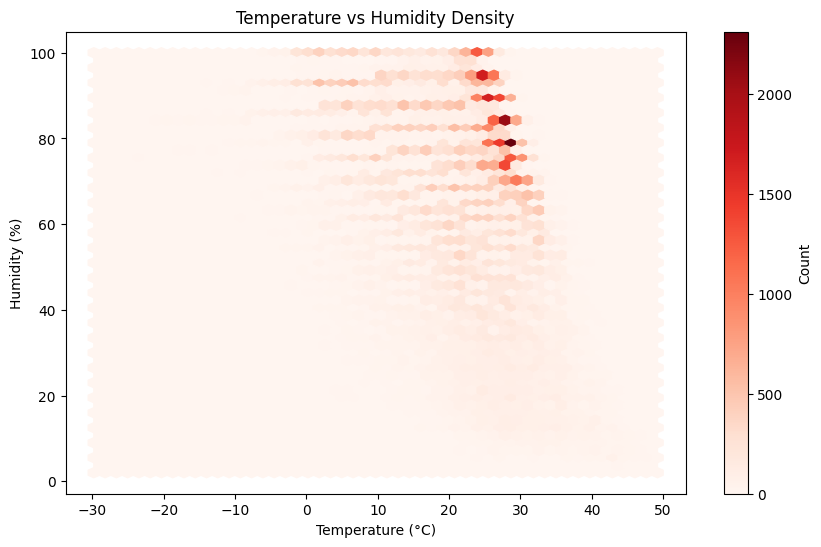

In [11]:
plt.figure(figsize=(10,6))

plt.hexbin(
    df['temperature_celsius'],
    df['humidity'],
    gridsize=50,
    cmap='Reds'
)

plt.colorbar(label='Count')

plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.title('Temperature vs Humidity Density')

plt.show()

In [13]:
df[['temperature_celsius', 'humidity']].corr()

,temperature_celsius,humidity
temperature_celsius,1.000000,-0.338948
humidity,-0.338948,1.000000


- Temperature and humidity exhibit a low inverse relationship.
- As temperatures increase, humidity generally decreases. 
- The highest concentration of observations occurs between 25–30°C and 70–90% humidity, indicating many locations experience warm and humid conditions.
- The triangular distribution suggests that while moderate temperatures can occur across a wide range of humidity levels, very high temperatures are less frequently associated with extremely high humidity.

## Wind Speed vs Pressure

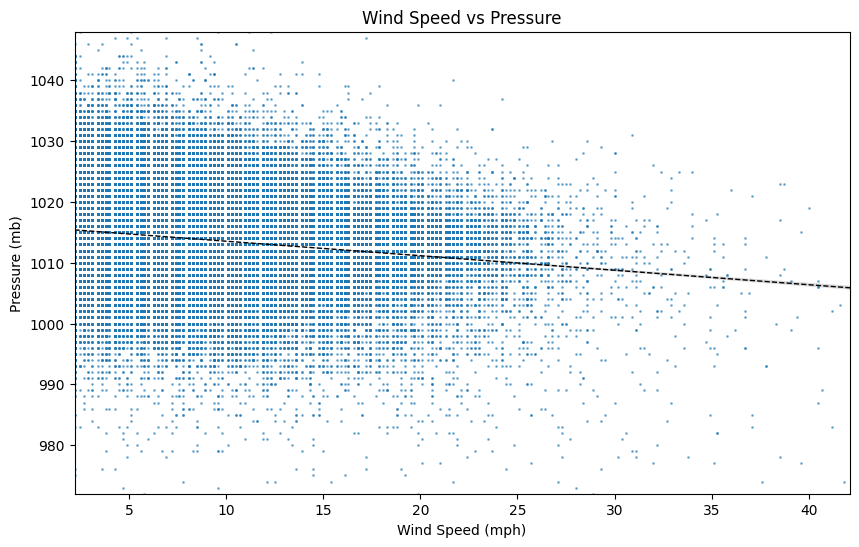

In [19]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='wind_mph',
    y='pressure_mb',
    scatter_kws={'s':1, 'alpha':0.5},
    line_kws={'linewidth':1, 'color':'black', 'linestyle':'--'}
)

plt.xlim(
    df['wind_mph'].quantile(0.0001),
    df['wind_mph'].quantile(0.9999)
)
plt.ylim(
    df['pressure_mb'].quantile(0.0001),
    df['pressure_mb'].quantile(0.9999)
)
plt.title('Wind Speed vs Pressure')
plt.xlabel('Wind Speed (mph)')
plt.ylabel('Pressure (mb)')

plt.show()

In [22]:
df[['wind_mph', 'pressure_mb']].corr()

,wind_mph,pressure_mb
wind_mph,1.000000,-0.178969
pressure_mb,-0.178969,1.000000


- Wind speed and atmospheric pressure exhibit only a weak negative relationship.
- Most observations occur between approximately 2–25 mph and 995–1030 mb, with considerable variability in pressure across all wind speeds.

## Cloud cover, Precipitation and Humidity

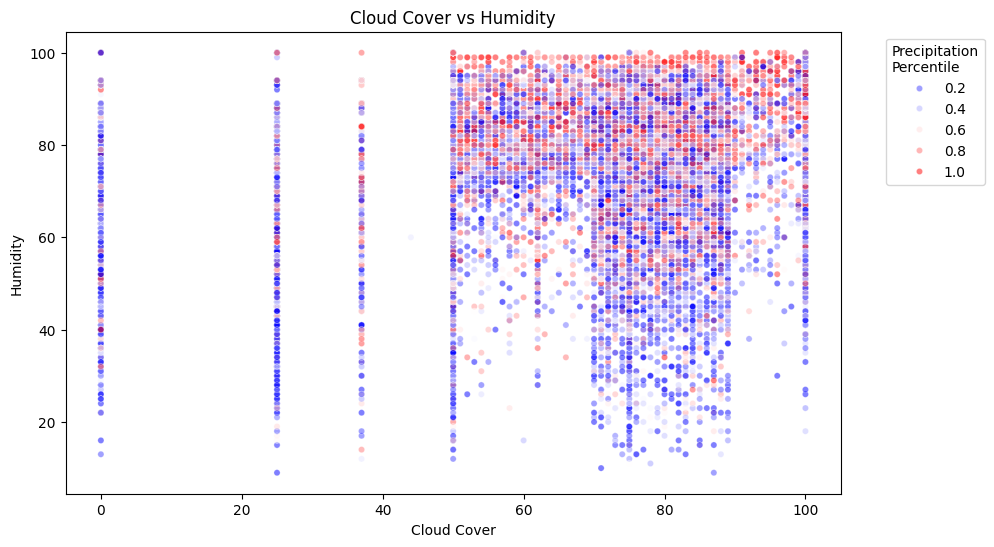

In [41]:
import numpy as np

plt.figure(figsize=(10,6))

# Handle zero inflated precipitation
# Take only pricip > 0
df_filtered = df[df['precip_mm'] > 0]

# Precip_mm is very skewed.
# Even taking log1p, it is still skewed.
# Scatterplot hue does not show much difference it makes.

# df_filtered['precip_log'] = np.log1p(df_filtered['precip_mm'])

# sns.scatterplot(
#     data=df_filtered,
#     x='cloud',
#     y='humidity',
#     hue='precip_log',
#     palette='bwr',
#     s=20,
#     alpha=0.5
# )

# Coloring my percentile rank of precip_mm instead of log1p
df_filtered['precip_pct'] = (
    df_filtered['precip_mm']
    .rank(pct=True)
)

sns.scatterplot(
    data=df_filtered,
    x='cloud',
    y='humidity',
    hue='precip_pct',
    palette='bwr',
    s=20,
    alpha=0.5
)

plt.legend(
    title='Precipitation\nPercentile',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.title('Cloud Cover vs Humidity')
plt.xlabel('Cloud Cover')
plt.ylabel('Humidity')

plt.show()

Higher precipitation percentiles are associated with higher humidity levels, while cloud cover shows a weaker relationship with precipitation intensity. This suggests humidity is a stronger indicator of rainfall intensity than cloud cover in this dataset.

- Cloud cover alone is not a strong predictor of precipitation intensity.
    - At cloud cover between roughly 50–100%, all precipitation percentiles are present.
    - Both light and heavy precipitation occur under similar cloud cover conditions.

- Humidity generally increases with precipitation percentile.
    - The red/orange points (higher precipitation percentiles) are concentrated toward higher humidity values.
    - Low humidity (<40%) is dominated by blue points (lower precipitation percentiles).

- High precipitation is rare when humidity is low.
    - The upper precipitation percentiles (red points) are mostly observed above about 70% humidity.

- Humidity appears more informative than cloud cover for explaining precipitation intensity.
    - Moving vertically (humidity) produces a clearer color gradient than moving horizontally (cloud cover).

## Visibility vs Air Pollution

<Axes: xlabel='pollution_score', ylabel='visibility_km'>

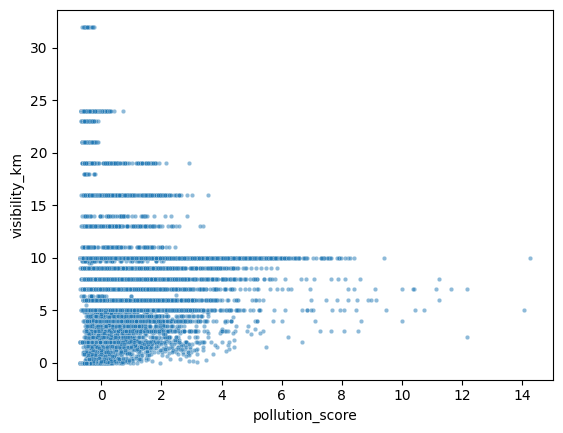

In [47]:
pollution_cols = [
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'air_quality_gb-defra-index'
]

from sklearn.preprocessing import StandardScaler

# Standardize each pollutant (mean=0, std=1) so they are on the same scale,
# then compute the average standardized pollution level for each observation
# to create a single overall air pollution score.
df['pollution_score'] = (
    StandardScaler()
    .fit_transform(df[pollution_cols])
    .mean(axis=1)
)

sns.scatterplot(
    data=df,
    x='pollution_score',
    y='visibility_km',
    alpha=0.5,
    s=10
)

Visibility exhibits a weak-to-moderate negative relationship with the composite pollution score. While visibility varies substantially at low pollution levels, high visibility observations occur almost exclusively under low-pollution conditions. As pollution increases, the maximum observed visibility decreases, suggesting that elevated air pollution may constrain visibility even though additional meteorological factors also influence viewing distance.

# Geographic Analysis

## Temperature vs Latitude

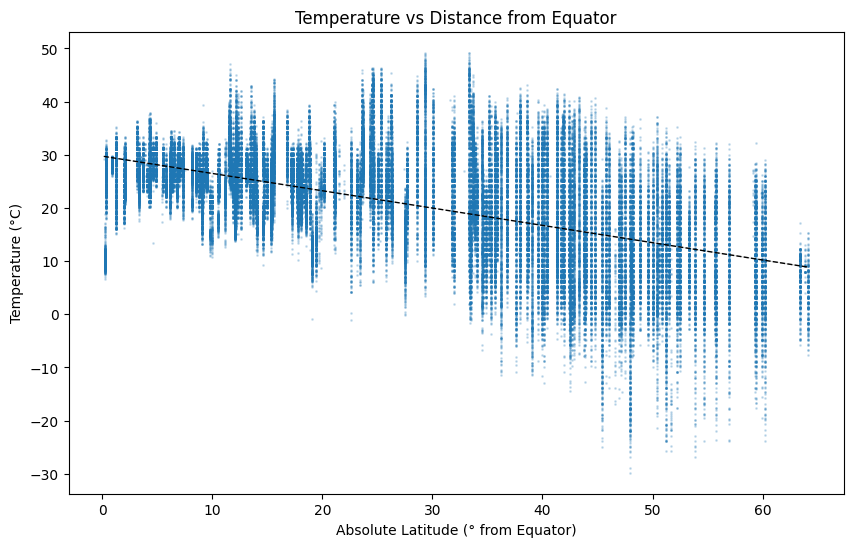

In [ ]:
# Taking absolute value of latitude to see distance from equator instead of north/south hemisphere

df['abs_latitude'] = df['latitude'].abs()

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='abs_latitude',
    y='temperature_celsius',
    scatter_kws={'s':1, 'alpha':0.2},
    line_kws={'linewidth':1, 'color':'black', 'linestyle':'--'}
)

plt.title('Temperature vs Distance from Equator')
plt.xlabel('Absolute Latitude (° from Equator)')
plt.ylabel('Temperature (°C)')

plt.show()

Temperatures generally decrease with increasing distance from the equator, confirming latitude as a major determinant of climate. Nevertheless, the substantial spread of observations at each latitude indicates that local geographic and seasonal factors also play an important role in determining temperature.

## UV Index vs Latitude

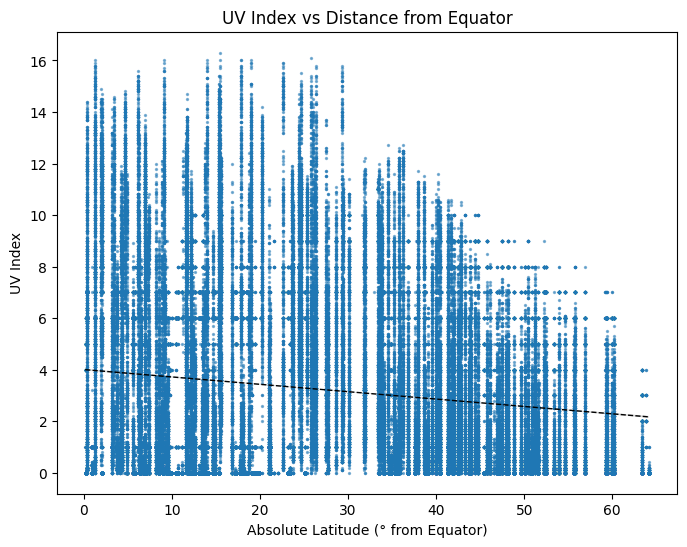

In [60]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='abs_latitude',
    y='uv_index',
    scatter_kws={'s':2, 'alpha':0.5},
    line_kws={'linewidth':1, 'color':'black', 'linestyle':'--'}
)

plt.title('UV Index vs Distance from Equator')
plt.xlabel('Absolute Latitude (° from Equator)')
plt.ylabel('UV Index')

plt.show()

UV index generally decreases as distance from the equator increases. Locations closer to the equator experience higher and more variable UV levels, while higher latitudes tend to have lower UV exposure. The wide spread of values suggests that latitude is an important but not exclusive determinant of UV intensity.

## Hemisphere comparison

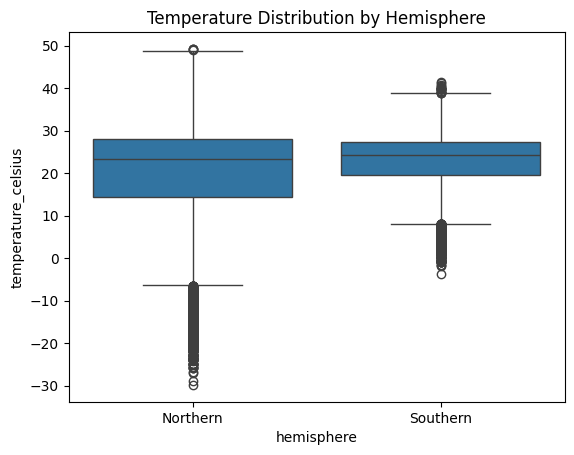

In [67]:
df['hemisphere'] = np.where(
    df['latitude'] >= 0,
    'Northern',
    'Southern'
)

sns.boxplot(
    data=df,
    x='hemisphere',
    y='temperature_celsius'
)

plt.title('Temperature Distribution by Hemisphere')
plt.show()

The Southern Hemisphere exhibits a slightly higher median temperature, while the Northern Hemisphere shows substantially greater temperature variability. The Northern Hemisphere contains both the coldest and warmest observations, likely due to its larger landmass and more continental climates. In contrast, the ocean-dominated Southern Hemisphere experiences a more moderate temperature range.

## Climate zones

In [71]:
df['latitude'].abs().max()

np.float64(64.15)

In [75]:
def climate_zone(latitude):
    latitude = abs(latitude)

    if latitude < 23.5:
        return 'Tropical'
    elif latitude < 40:
        return 'Subtropical'
    elif latitude < 60:
        return 'Temperate'
    else:
        return 'Subpolar'
    
df['climate_zone'] = df['latitude'].apply(climate_zone)

df['climate_zone'].value_counts()

climate_zone
Tropical       71608
Temperate      37275
Subtropical    33673
Subpolar        1478
Name: count, dtype: int64

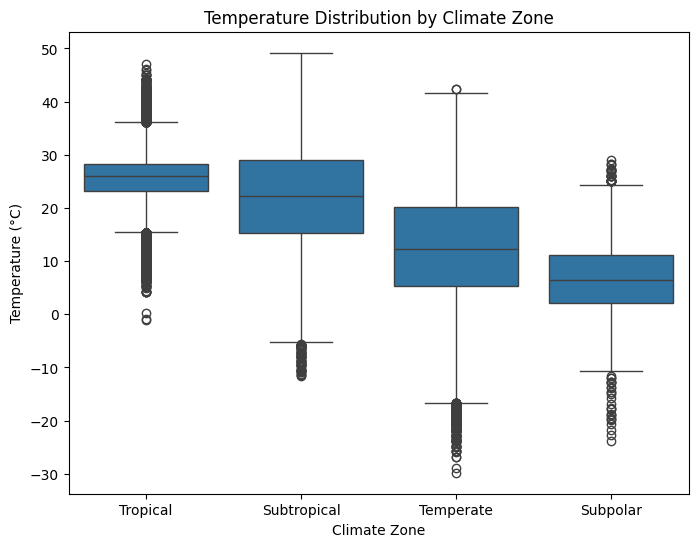

In [76]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='climate_zone',
    y='temperature_celsius',
    order=['Tropical', 'Subtropical', 'Temperate', 'Subpolar']
)

plt.title('Temperature Distribution by Climate Zone')
plt.xlabel('Climate Zone')
plt.ylabel('Temperature (°C)')

plt.show()

Temperature distributions vary substantially across climate zones. Median temperatures decrease progressively from Tropical to Subpolar regions, demonstrating the strong influence of latitude on climate. Tropical regions exhibit consistently warm temperatures with relatively low variability, whereas Temperate and Subpolar regions experience much broader temperature ranges due to stronger seasonal effects. The observed pattern aligns with expected global climate gradients, where locations farther from the equator receive less solar energy and therefore maintain lower average temperatures.

## Air Quality by Country

In [ ]:
# Country vs Daily Pollution Score
# Top 10 countries

# Some entries have local names for countries
print(df['country'].value_counts().sort_values(ascending=True).head(50))
print(len(df['country'].unique()))

valid_countries = (
    df['country']
      .value_counts()
      .loc[lambda x: x >= 3]
      .index
)

print(len(valid_countries))

country
Turkménistan                          1
火鸡                                    1
Jemen                                 1
Estonie                               1
Гватемала                             1
Inde                                  1
Letonia                               1
Польша                                1
Malásia                               1
Komoren                               1
كولومبيا                              1
Турция                                1
Saint-Vincent-et-les-Grenadines       1
Saudi Arabien                         1
Südkorea                              1
Bélgica                               1
Mexique                               1
Polônia                               1
Marrocos                              1
Togo                                  1
Lao People's Democratic Republic      1
Kosovo                                1
Libya                                 1
Colombia                              1
USA United States of America    

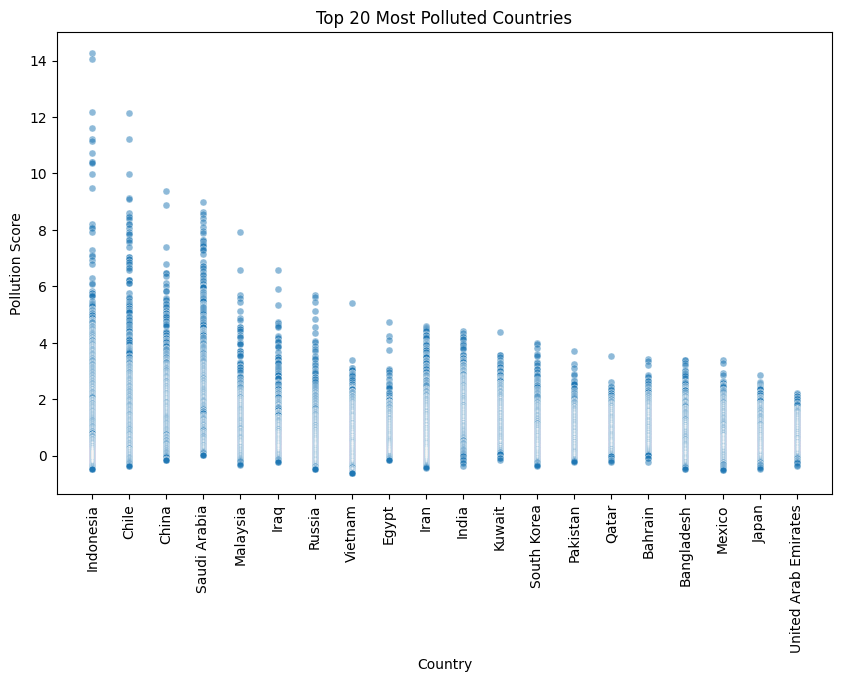

In [107]:
df_temp = df[df['country'].isin(valid_countries)]

top_countries = (
    df_temp.groupby('country')['pollution_score']
      .mean()
      .nlargest(20)
      .index
)

df_top = df_temp[df_temp['country'].isin(top_countries)]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_top.sort_values('pollution_score', ascending=False),
    x='country',
    y='pollution_score',
    alpha=0.5,
    s=25
)

plt.xticks(rotation=90)
plt.title('Top 20 Most Polluted Countries')
plt.xlabel('Country')
plt.ylabel('Pollution Score')

plt.show()

> Indonesia and Chile exhibit the highest pollution scores and the most extreme pollution events in the dataset. While most observations across all countries remain below a pollution score of 5, several countries experience occasional high-pollution spikes, indicating substantial temporal variability in air quality.


# Temporal Analysis
## Monthly average temperature
## Seasonal temperature patterns
## Air quality over time
## Precipitation seasonality
